# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Instantiate a `Session` object and define scenarios.

In [3]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [4]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [5]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('all')]
runs
# runs = [('Sust50','2050')]

[('Base20', '2020'),
 ('Base20', '2025'),
 ('Base20', '2030'),
 ('Base20', '2035'),
 ('Base20', '2040'),
 ('Base20', '2045'),
 ('Base20', '2050'),
 ('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [6]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

Base20, 2050 finished successfully in 3min 31s
Base20, 2040 finished successfully in 4min 18s
Base20, 2045 finished successfully in 4min 18s
Base20, 2020 finished successfully in 4min 22s
Sust50, 2020 finished successfully in 4min 28s
Base20, 2025 finished successfully in 4min 38s
Base20, 2030 finished successfully in 4min 39s
Base20, 2035 finished successfully in 4min 40s
Sust50, 2025 finished successfully in 2min 5s
Sust50, 2030 finished successfully in 2min 43s
Sust50, 2050 finished successfully in 2min 41s
Sust50, 2045 finished successfully in 2min 56s
Sust50, 2040 finished successfully in 3min 11s
Sust50, 2035 finished successfully in 3min 17s
CPU times: total: 31.2 ms
Wall time: 7min 42s


## Plot output

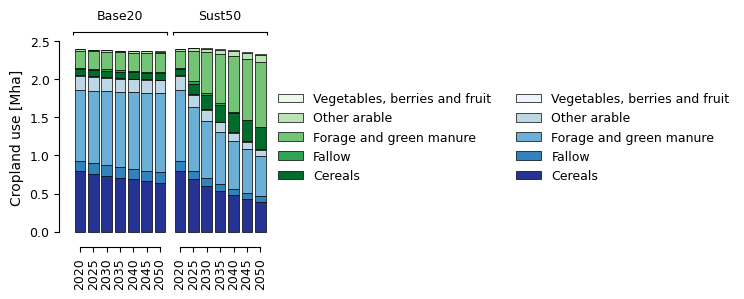

prod_system  conventional    organic  total
scn    year                                
Base20 2020     85.814624  14.185376  100.0
       2025     85.527159  14.472841  100.0
       2030     85.255995  14.744005  100.0
       2035     85.010627  14.989373  100.0
       2040     84.774128  15.225872  100.0
       2045     84.547250  15.452750  100.0
       2050     84.349275  15.650725  100.0
Sust50 2020     85.814624  14.185376  100.0
       2025     74.782377  25.217623  100.0
       2030     66.701699  33.298301  100.0
       2035     60.270055  39.729945  100.0
       2040     54.951030  45.048970  100.0
       2045     50.534869  49.465131  100.0
       2050     46.776875  53.223125  100.0

prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.054233  0.339570  2.393803
       2025      2.042469  0.345625  2.388094
       2030      2.029843  0.351037  2.380880
       2035      2.017198  0.355680  2.372878
       2040      2.008232  0.360689  2.368921
       2045      2.001848  0.365879  2.367727
       2050      1.994685  0.370107  2.364792
Sust50 2020      2.054233  0.339570  2.393803
       2025      1.804023  0.608341  2.412363
       2030      1.604310  0.800891  2.405201
       2035      1.443458  0.951526  2.394984
       2040      1.307204  1.071649  2.378853
       2045      1.191736  1.166509  2.358245
       2050      1.088190  1.238152  2.326342

In [7]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, fontsize=9, frameon=False, reverse=True)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
display(tab_data)

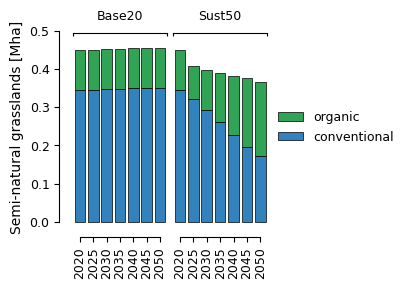

In [8]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

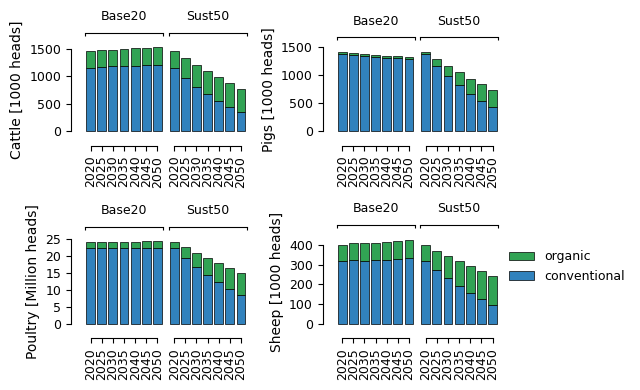

In [9]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [10]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.349617  21.228135   
Barley, spring                      conventional   5.017222   5.979550   
Barley, winter                      conventional   6.376670   7.601222   
Beans, dry                          conventional   1.768469   1.768864   
Broad beans and horse beans, dry    conventional   3.290752   4.126376   
Buckwheat                           conventional   1.580422   1.594228   
Cabbages, cauliflowers and broccoli conventional  21.719118  27.101337   
Carrots                             conventional  67.419062  85.568317   
Cereals for fodder                  conventional   3.493201   3.497601   
Cucumbers                           conventional  62.166506  63.397853   
Currants                            conventional   1.481360   1.501738   
Energy grass                        conventional   4.027580   4.027127   
Fallow                              conventional   2.333532   2.331942   
Green manure                        conventional   4.806995   4.809530   
Hazelnuts                           conventional   0.953436   0.980949   
Herbs                               conventional   4.007669   5.101798   
Lettuce and spinach                 conventional  15.537258  19.694113   
Ley for fodder                      conventional   5.509389   5.524243   
Ley for grazing                     conventional   4.446253   4.477995   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.972666   3.970792   
Maize (corn)                        conventional   6.100138   6.102494   
Maize for forage and silage         conventional  10.756862  10.729494   
Mixed cereals                       conventional   3.331334   3.302300   
Oats                                conventional   4.619917   5.748651   
Onions                              conventional  51.321895  65.067885   
Other berries                       conventional   1.698998   1.768338   
Other crops for fodder              conventional   4.337702   4.351511   
Other fruit                         conventional   4.564604   4.586003   
Other root vegetables               conventional  34.838654  43.986379   
Other vegetables                    conventional  14.950928  18.566057   
Pears                               conventional  15.677668  15.726270   
Peas, dry                           conventional   3.414730   4.271971   
Peas, green                         conventional   4.405796   4.422554   
Potatoes, starch                    conventional  45.159234  55.111682   
Potatoes, table                     conventional  38.306503  46.641823   
Pumpkins and squash                 conventional  27.267127  34.126383   
Rapeseed, spring                    conventional   1.837205   2.199539   
Rapeseed, winter                    conventional   3.553707   4.258567   
Rye                                 conventional   6.905359   8.624232   
Short rotation coppice              conventional   4.695393   4.694593   
Strawberries                        conventional   6.878584   6.888588   
Sugar beet                          conventional  76.519129  95.612341   
Triticale, spring                   conventional   3.314987   3.320352   
Triticale, winter                   conventional   5.759942   5.757613   
Walnuts                             conventional   1.026273   1.029620   
Wheat, spring                       conventional   4.630356   6.301381   
Wheat, winter                       conventional   7.248003   9.907214   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.113651   8.108454   8.190818
Barley, spring                   organic       3.181706   3.281929   4.574017
Barley, winter                   organic       3.970397   4.088789   4.427665
Beans, dry                       organic       1.401294   1.695912   1.877359
Broad beans and horse beans, dry organic       2.361739   2.726260   3.534101
Buckwheat                        organic       1.291117        inf   0.786872
Carrots                          organic      58.646175  74.530517  80.825037
Cereals for fodder               organic       3.079960   3.078993   3.001219
Cucumbers                        organic      10.482327  13.310203  14.195567
Energy grass                     organic       3.570565   3.567664   4.161246
Fallow                           organic       2.240963   2.238527   2.115885
Green manure                     organic       4.500310   4.499721   4.718964
Hazelnuts                        organic       1.047401        inf   0.800000
Herbs                            organic       0.877410   1.113576   0.411520
Lettuce and spinach              organic       5.840186   7.418645   8.087908
Ley for fodder                   organic       4.729326   4.734524   4.644793
Ley for grazing                  organic       3.796983   3.819985   3.682779
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.541791   3.542321   3.352146
Maize (corn)                     organic       3.941140   3.941336   4.110314
Mixed cereals                    organic       2.728909   2.749581   4.236269
Oats                             organic       2.999367   3.120454   4.165907
Onions                           organic      25.815639  32.789529  35.995394
Other crops for fodder           organic       3.579109   3.586035   3.322240
Other root vegetables            organic       7.245330   9.204441  10.223946
Other vegetables                 organic       3.170566   4.026040   4.541333
Pears                            organic       5.476809   5.474227   5.529317
Peas, dry                        organic       2.623294   3.032911   3.559902
Potatoes, starch                 organic            NaN        NaN  42.344287
Potatoes, table                  organic      26.005565  31.919454  35.213358
Rapeseed, spring                 organic       0.730705   0.967778   1.250664
Rapeseed, winter                 organic       2.134589   2.840946   3.248410
Rye                              organic       3.852909   5.405796   6.859031
Short rotation coppice           organic       4.475796   4.468859   4.977203
Triticale, spring                organic       2.109707   2.111032        NaN
Triticale, winter                organic       4.230574   4.229025   4.484280
Walnuts                          organic       1.384921        inf        NaN
Wheat, spring                    organic       2.913136   3.627006   4.187141
Wheat, winter                    organic       4.417085   5.508767   5.946405

scn     year
Base20  2020     0.740598
        2025     0.728622
        2030     0.718018
        2035     0.708764
        2040     0.698909
        2045     0.688984
        2050     0.681103
Sust50  2020     0.740598
        2025    10.704320
        2030    16.044101
        2035    19.568626
        2040    22.165941
        2045    24.226074
        2050    24.209341
Name: Green manure, dtype: float64

scn     year
Base20  2020    148.613299
        2025    147.354553
        2030    146.033500
        2035    144.664362
        2040    143.478943
        2045    142.405567
        2050    141.255964
Sust50  2020    148.613299
        2025    137.408779
        2030    124.768610
        2035    113.583948
        2040    103.946752
        2045     95.825707
        2050     89.100832
Name: value, dtype: float64

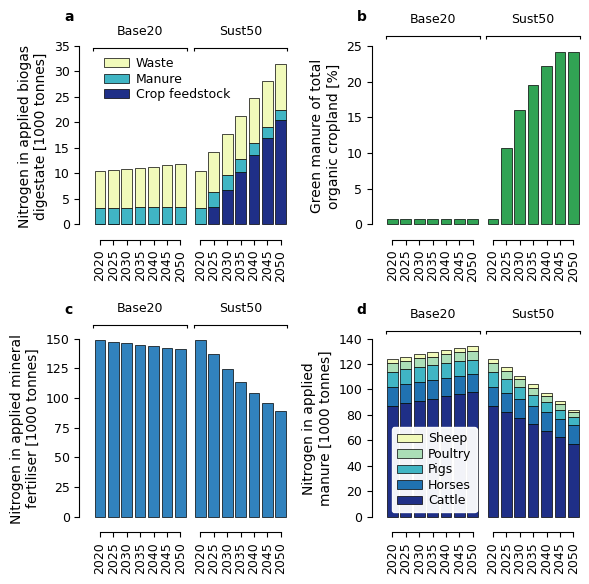

In [11]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

# Annotate
for i, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.2, chr(97 + i), transform=ax.transAxes, 
            fontsize=10, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

In [12]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    250.676642  32.194631
       2025    251.122131  32.745944
       2030    251.292601  33.230048
       2035    251.228591  33.642914
       2040    251.432063  34.083281
       2045    251.777758  34.537883
       2050    251.864746  34.915981
Sust50 2020    250.676642  32.194631
       2025    226.312675  42.492527
       2030    205.561686  47.616373
       2035    187.049227  51.750607
       2040    170.532869  55.505508
       2045    155.425853  59.333420
       2050    141.449799  63.180859

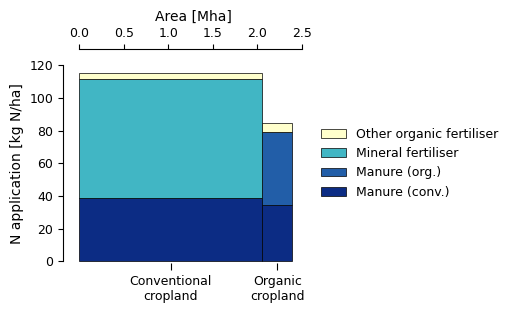

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,38.826143,0.269315,72.267548,4.147992,115.510999
Organic\ncropland,34.695511,44.539308,NaN,5.496536,84.731355


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.025192,0.229077,61.47017,3.528247
Organic\ncropland,40.784217,52.355500,NaN,6.461122


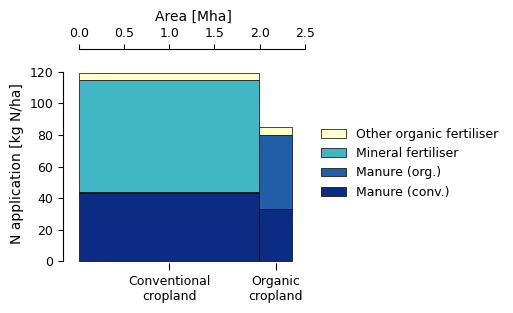

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,43.580008,0.293789,70.718722,4.893517,119.486036
Organic\ncropland,33.192085,46.515427,NaN,5.355206,85.062717


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,35.874012,0.241840,58.213947,4.028225
Organic\ncropland,38.851677,54.446785,NaN,6.268324


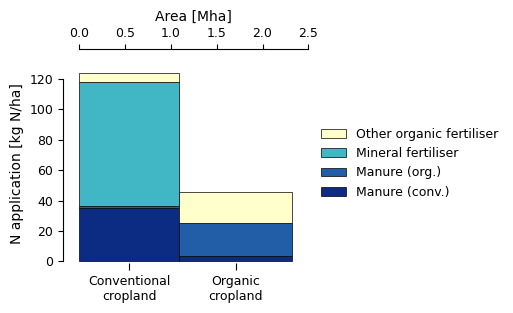

,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,35.265407,1.113872,81.726641,6.001771,124.107691
Organic\ncropland,3.275311,22.196307,NaN,20.192906,45.664524


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,28.168185,0.889703,65.279017,4.793905
Organic\ncropland,6.983207,47.324181,NaN,43.052780


In [13]:
scn = 'SCN'

for scn, year in [('Base20','2020'),('Base20','2050'),('Sust50','2050')]:
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    from matplotlib.colors import ListedColormap
    colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
    cust_cmap = ListedColormap(name='X', colors=colors)
    
    fig, ax = plt.subplots(figsize=(3,2.6))
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.08,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )
    
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    
    plt.show()
    fig.savefig(os.path.join(session.data_path_output,'figs',f'N-boxes {scn}_{year}.pdf'), format='pdf', bbox_inches="tight")

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)

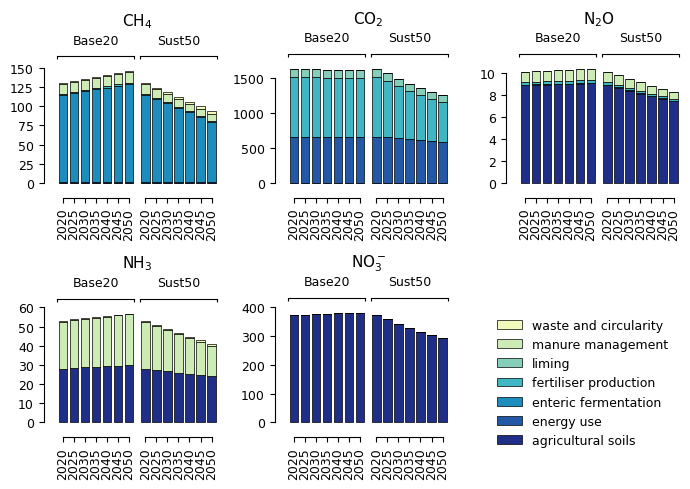

In [14]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3-N' : (17/14),
    'NO3-N' : (62/14)
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$'
}

ems = (
    cm.get_emissions(session)
    .drop(['NOx-N','CO2bio','N2'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **bar_style
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
# tab_data['CO$_2$eq'] = tab_data.mul(pd.Series({'CO$_2$':1, 'CH$_4$':25, 'N$_2$O':298}), axis=1).sum(axis=1)
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

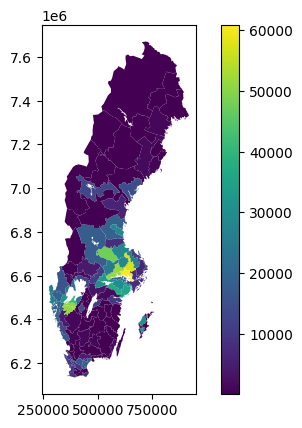

In [23]:
cm.plot.map_from_series(
    session.get_attr('c','area',{'crop':'land_use','prod_system':None,'region':None}).loc[('Sust50','2050'),('cropland','organic')]
)

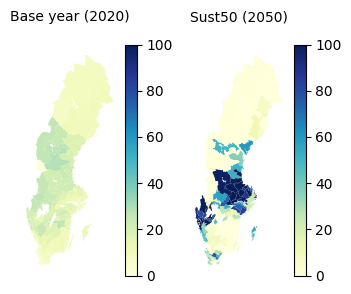

In [37]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,2, figsize=(4,3))

ax=axs[0]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Base year (2020)', fontsize=10)

ax=axs[1]
cm.plot.map_from_series(
    plot_data.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax
)
ax.axis('off')
ax.set_title('Sust50 (2050)', fontsize=10)

plt.show()

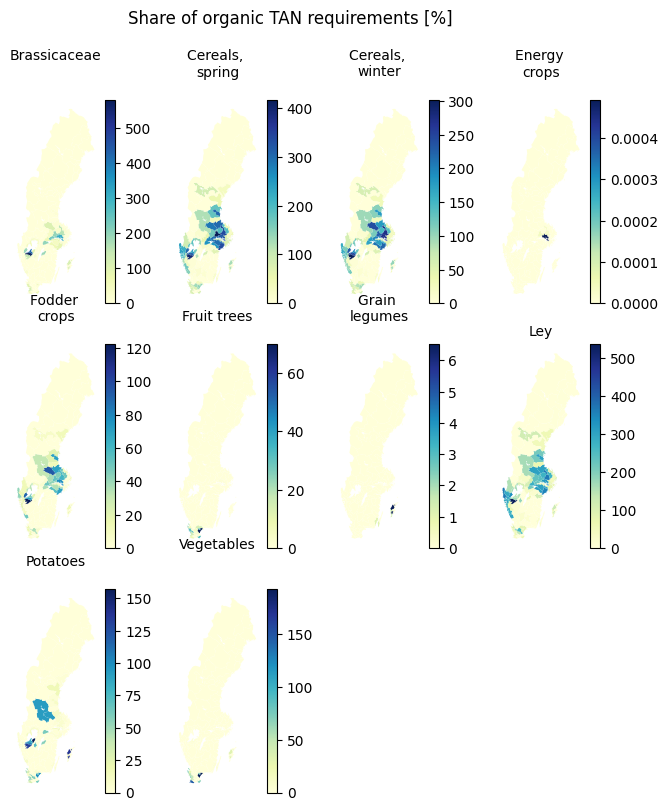

In [16]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic TAN requirements [%]')
plt.show()

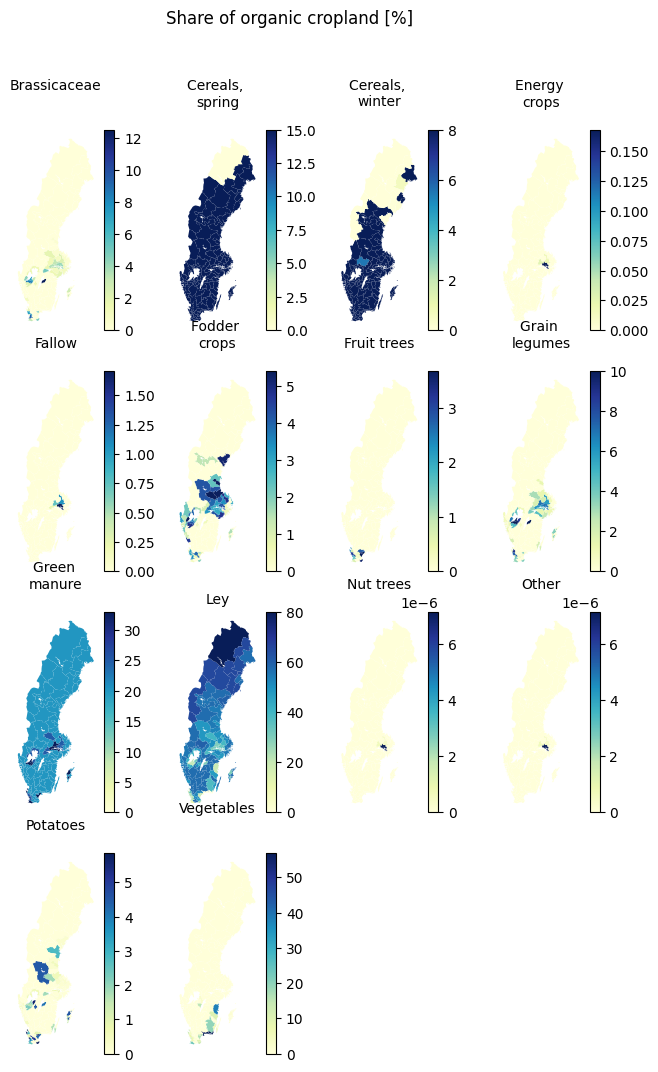

In [17]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

In [18]:
session.get_attr('c','fertiliser.crop_residues_N_soil_loss',['crop']).apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

scn     year
Base20  2020     0.151447
        2025     0.149551
        2030     0.147767
        2035     0.146143
        2040     0.144426
        2045     0.142711
        2050     0.141231
Sust50  2020     0.151447
        2025     2.920586
        2030     5.639578
        2035     8.084579
        2040    10.245761
        2045    12.154663
        2050    13.000265
Name: Green manure, dtype: float64

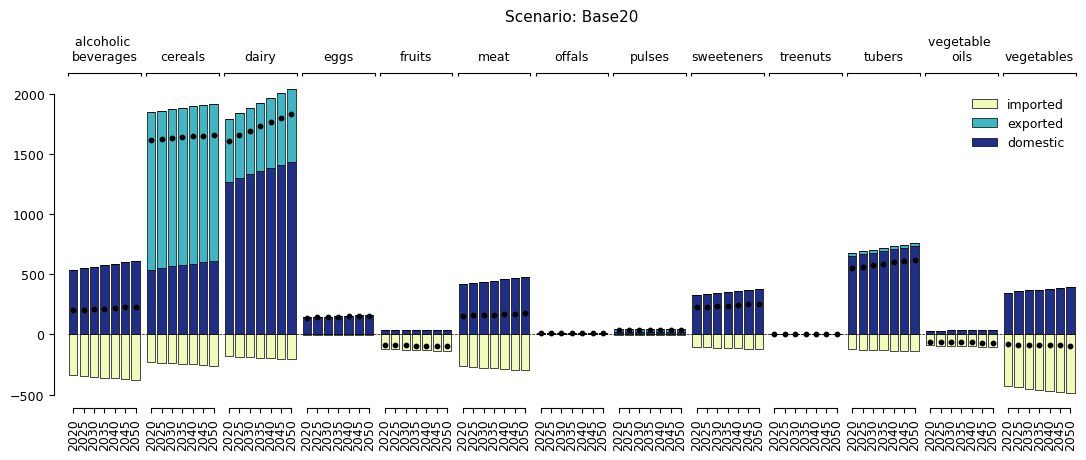

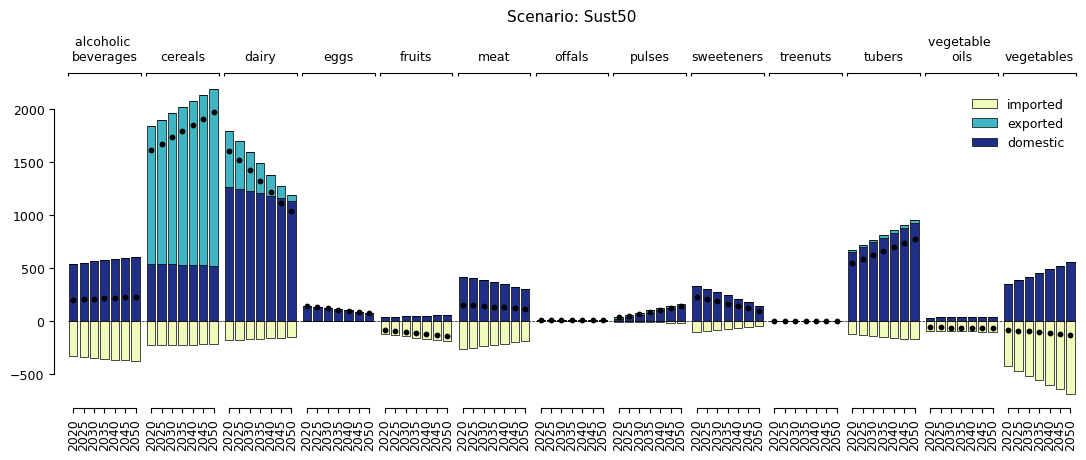

In [19]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax, **bar_style)
    plt.show()